In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('churn.csv')

In [3]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
911,7508-SMHXL,Female,1,No,No,15,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,No,Credit card (automatic),89.00,1288.3,No
4972,1987-AUELQ,Female,0,Yes,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.05,1873.7,No
1515,1921-KYSAY,Female,0,No,No,41,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,One year,Yes,Electronic check,68.60,2877.05,No
5293,2242-MFOTG,Male,0,No,No,33,Yes,Yes,Fiber optic,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),80.10,2603.3,No
1382,4538-WNTMJ,Female,0,Yes,Yes,46,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,24.95,1165.9,No


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.shape

(7043, 21)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [12]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

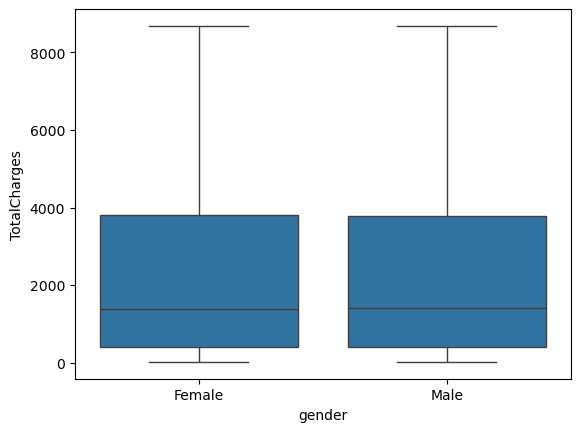

In [13]:
sns.boxplot(x=df['gender'],y=df['TotalCharges'])
plt.show()

In [14]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [15]:
df.select_dtypes(include='number').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

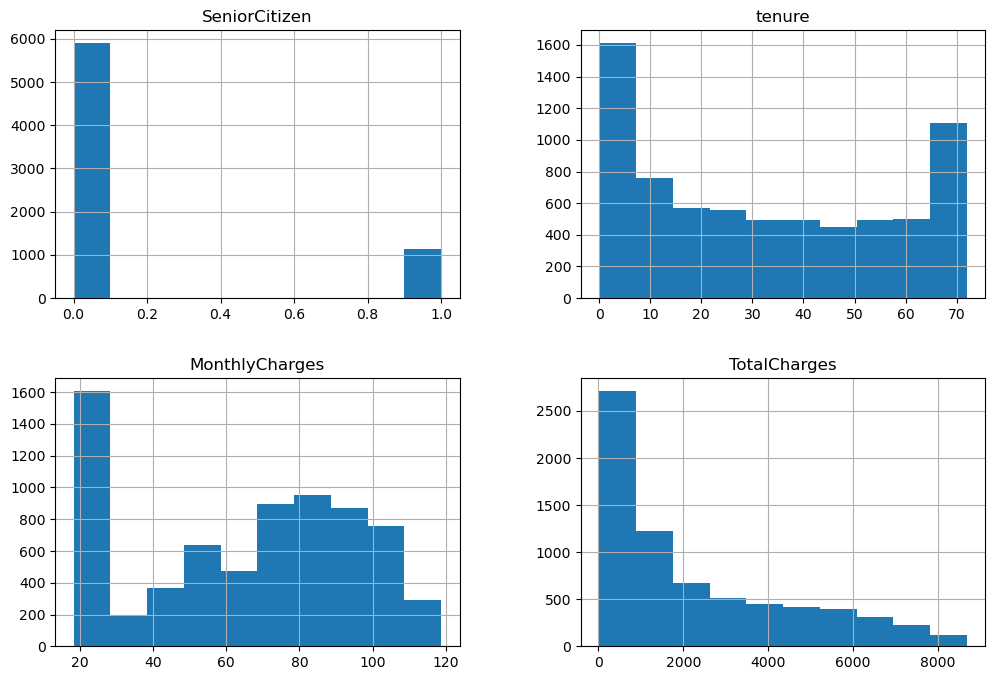

In [16]:
df.select_dtypes(include='number').hist(figsize=(12,8))
plt.show()

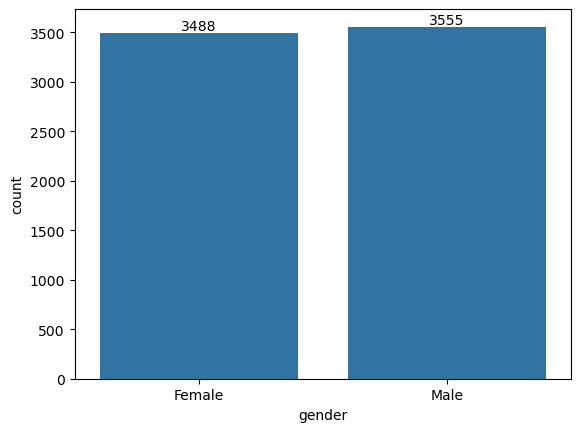

In [17]:
ax = sns.countplot(x='gender',data=df)
for container in ax.containers:
    ax.bar_label(container) 

plt.show()

<Axes: xlabel='Contract', ylabel='count'>

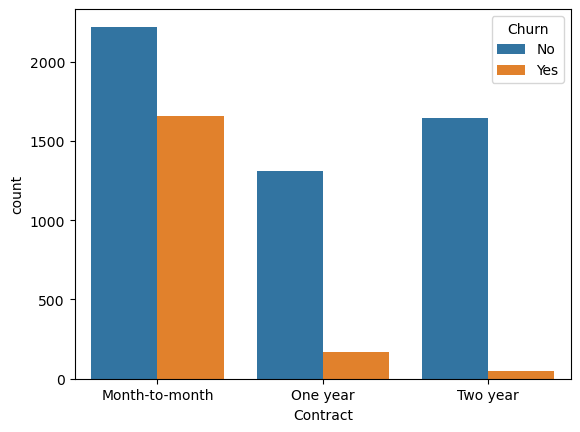

In [18]:
sns.countplot(x='Contract',hue='Churn',data=df)

In [19]:
numeric_cols = df.select_dtypes(include='object').columns

In [20]:
for col in numeric_cols:
    print(df[col].value_counts())

customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes               

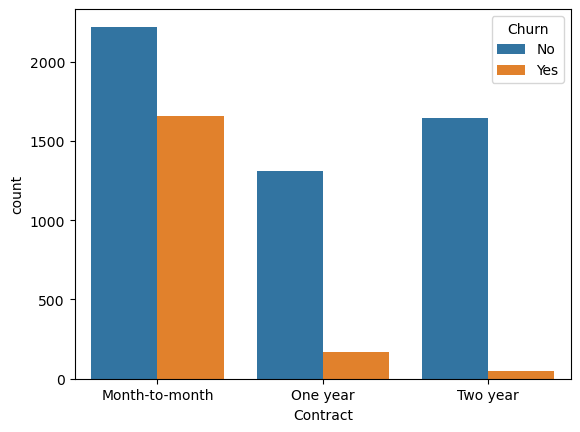

In [21]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

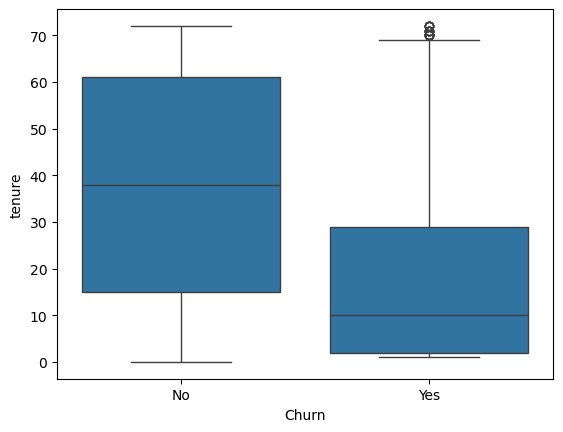

In [22]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

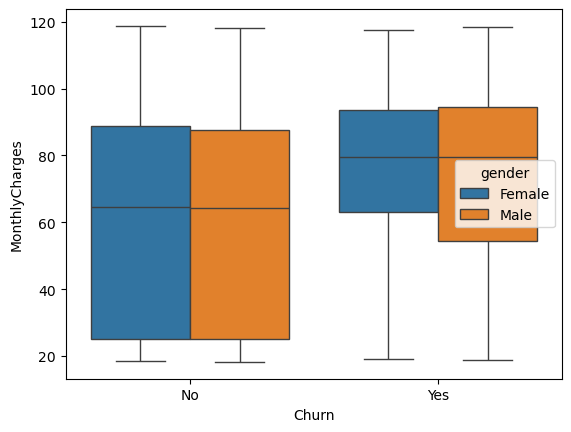

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', hue='gender',data=df)
plt.show()

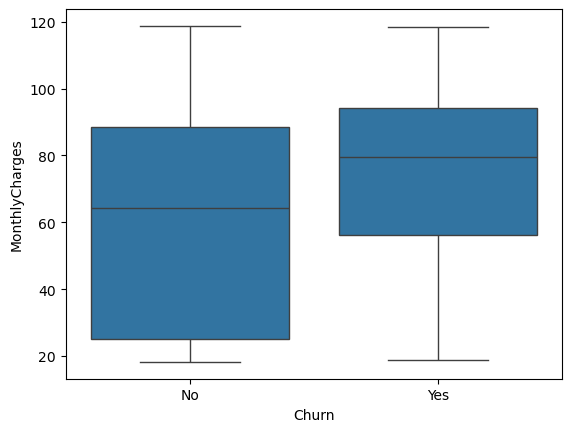

In [24]:
sns.boxplot(x='Churn', y='MonthlyCharges',data=df)
plt.show()

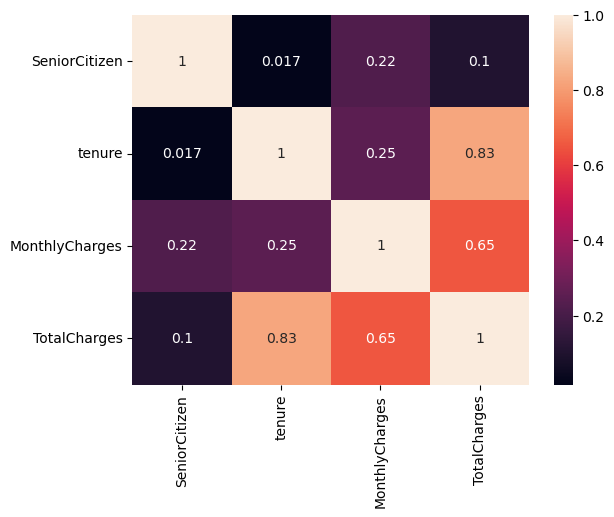

In [25]:
numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.show()

In [26]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


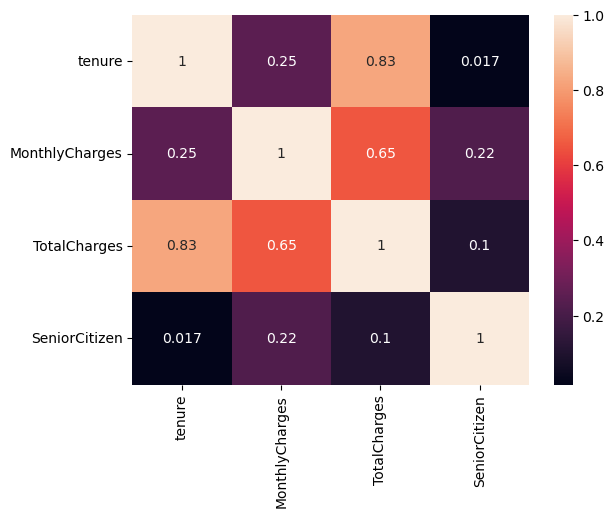

In [27]:
sns.heatmap(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].corr(),
    annot=True
)
plt.show()

In [28]:
df.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [29]:
df.select_dtypes(include='object').nunique()

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
Churn                  2
dtype: int64

In [30]:
df.drop('customerID', axis=1, inplace=True)

In [31]:
X=df.drop(columns=['Churn'])
y=df['Churn']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [32]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.70
6227,Male,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35
4673,Female,1,No,No,25,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.20
2710,Female,0,Yes,No,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.80


In [33]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,Female,0,Yes,Yes,49,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,87.20,4345.00
4439,Male,0,Yes,Yes,28,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.30,487.95
3857,Male,0,No,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.65,93.55
4758,Female,0,No,No,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.90


In [34]:
y_train

3738     No
3151     No
4860     No
3867     No
3810     No
       ... 
6303     No
6227    Yes
4673    Yes
2710     No
5639     No
Name: Churn, Length: 5634, dtype: object

## Pipeline-Based Preprocessing

From this point onward, preprocessing is handled inside a single scikit-learn pipeline. No separate `fit_transform()` calls are used for imputation, encoding, or scaling.

In [35]:
# Imports for pipeline-based preprocessing and modeling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt


### Define features and target

In [36]:
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


### Feature groups

In [37]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Single preprocessing pipeline

In [38]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])


### Logistic Regression pipeline

In [39]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))


Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664


### Balanced Logistic Regression

In [40]:
lr_balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_balanced_pipeline.fit(X_train, y_train)

y_pred_lr_balanced = lr_balanced_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr_balanced))
print("Precision:", precision_score(y_test, y_pred_lr_balanced))
print("Recall   :", recall_score(y_test, y_pred_lr_balanced))
print("F1 Score :", f1_score(y_test, y_pred_lr_balanced))


Accuracy : 0.7381121362668559
Precision: 0.504302925989673
Recall   : 0.7834224598930482
F1 Score : 0.6136125654450262


### Decision Tree

In [41]:
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))


Accuracy : 0.7409510290986515
Precision: 0.5125348189415042
Recall   : 0.4919786096256685
F1 Score : 0.5020463847203275


### Balanced Decision Tree

In [42]:
tree_balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

tree_balanced_pipeline.fit(X_train, y_train)
y_pred_tree_balanced = tree_balanced_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_tree_balanced))
print("Precision:", precision_score(y_test, y_pred_tree_balanced))
print("Recall   :", recall_score(y_test, y_pred_tree_balanced))
print("F1 Score :", f1_score(y_test, y_pred_tree_balanced))


Accuracy : 0.730305180979418
Precision: 0.4918918918918919
Recall   : 0.48663101604278075
F1 Score : 0.489247311827957


### Random Forest

In [43]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))


Accuracy : 0.7856635911994322
Precision: 0.6216216216216216
Recall   : 0.4919786096256685
F1 Score : 0.5492537313432836


### Balanced Random Forest

In [44]:
rf_balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

rf_balanced_pipeline.fit(X_train, y_train)
y_pred_rf_balanced = rf_balanced_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf_balanced))
print("Precision:", precision_score(y_test, y_pred_rf_balanced))
print("Recall   :", recall_score(y_test, y_pred_rf_balanced))
print("F1 Score :", f1_score(y_test, y_pred_rf_balanced))


Accuracy : 0.7750177430801988
Precision: 0.5673758865248227
Recall   : 0.6417112299465241
F1 Score : 0.6022584692597239


### K-Nearest Neighbors

In [45]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))


Accuracy : 0.7665010645848119
Precision: 0.5596816976127321
Recall   : 0.5641711229946524
F1 Score : 0.5619174434087882


### Support Vector Machine

In [46]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42, probability=True))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))


Accuracy : 0.7927608232789212
Precision: 0.6496350364963503
Recall   : 0.47593582887700536
F1 Score : 0.5493827160493827


## Model Comparison with Cross-Validation

In [47]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
    "KNN": knn_pipeline,
    "SVM": svm_pipeline
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )
    cv_results[name] = scores

    print(f"{name}")
    print("F1 scores:", scores)
    print("Mean F1 :", scores.mean())
    print("Std     :", scores.std())
    print()


Logistic Regression
F1 scores: [0.58608059 0.54945055 0.58627087 0.64359862 0.60113422]
Mean F1 : 0.5933069677868387
Std     : 0.030382983212330923

Decision Tree
F1 scores: [0.48595041 0.47761194 0.51913478 0.46329527 0.5375626 ]
Mean F1 : 0.49671100048092354
Std     : 0.027454889020126022

Random Forest
F1 scores: [0.53159851 0.51711027 0.58601134 0.53435115 0.56804734]
Mean F1 : 0.5474237207284265
Std     : 0.025513028237794246

KNN
F1 scores: [0.53264605 0.53641208 0.56742557 0.55921053 0.56206897]
Mean F1 : 0.5515526374545264
Std     : 0.014197760638995574

SVM
F1 scores: [0.56237624 0.54095238 0.57587549 0.58867925 0.57936508]
Mean F1 : 0.569449685921113
Std     : 0.016562076882156766



## ROC-AUC and PR-AUC

In [48]:
lr_pipeline.fit(X_train, y_train)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

print("ROC-AUC:", roc_auc_lr)
print("PR-AUC :", pr_auc_lr)


ROC-AUC: 0.8420083184789068
PR-AUC : 0.6348201788804793


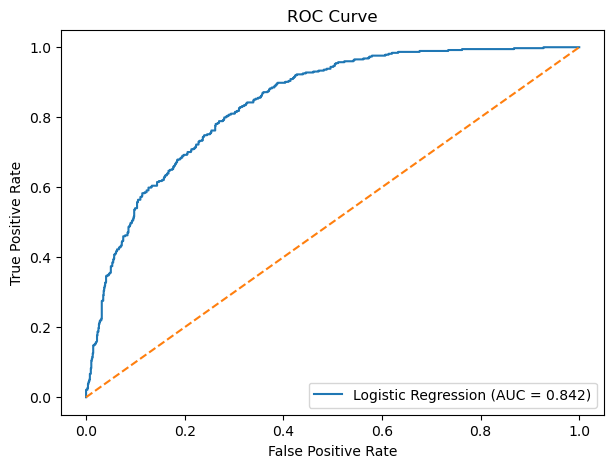

In [49]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


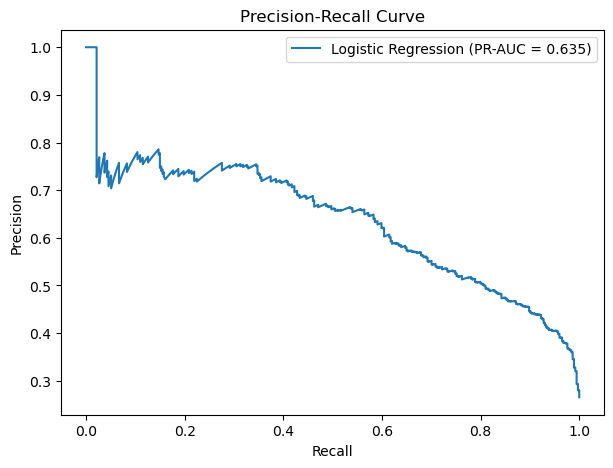

In [50]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (PR-AUC = {pr_auc_lr:.3f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


## Threshold Tuning

In [51]:
# Out-of-fold probabilities from the complete pipeline
y_train_prob = cross_val_predict(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = []

for threshold in thresholds:
    y_pred = (y_train_prob >= threshold).astype(int)
    f1_scores.append(f1_score(y_train, y_pred))

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best CV F1:", f1_scores[best_index])


Best threshold: 0.32999999999999985
Best CV F1: 0.6366782006920415


In [52]:
CHURN_THRESHOLD = 0.33

lr_pipeline.fit(X_train, y_train)

y_test_probability = lr_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probability >= CHURN_THRESHOLD).astype(int)

print("Threshold used:", CHURN_THRESHOLD)


Threshold used: 0.33


## Final Test Evaluation

In [53]:
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_probability))
print("PR-AUC   :", average_precision_score(y_test, y_test_probability))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Accuracy : 0.7615330021291696
Precision: 0.538
Recall   : 0.7192513368983957
F1 Score : 0.6155606407322655
ROC-AUC  : 0.8420083184789068
PR-AUC   : 0.6348201788804793

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



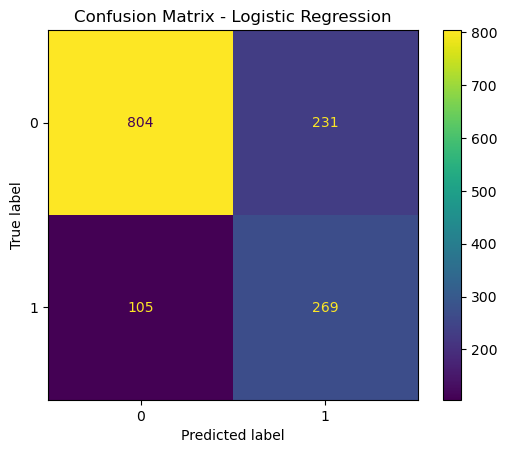

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


## Train vs Validation F1

In [55]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results_lr = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print("Mean Train F1:", cv_results_lr['train_f1'].mean())
print("Mean Validation F1:", cv_results_lr['test_f1'].mean())
print("F1 Gap:", cv_results_lr['train_f1'].mean() - cv_results_lr['test_f1'].mean())


Mean Train F1: 0.6023903177045307
Mean Validation F1: 0.5933069677868387
F1 Gap: 0.009083349917691996


## Final Deployment Pipeline

In [56]:
# This is the only object needed for deployment.
# It contains preprocessing + Logistic Regression together.

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

print(final_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
               

## Save Complete Pipeline

In [57]:
import joblib

MODEL_PATH = "churn_pipeline.pkl"

joblib.dump(final_pipeline, MODEL_PATH)

print(f"Pipeline saved to: {MODEL_PATH}")


Pipeline saved to: churn_pipeline.pkl


## Load and Verify Saved Pipeline

In [58]:
loaded_pipeline = joblib.load(MODEL_PATH)

loaded_probability = loaded_pipeline.predict_proba(X_test)[:, 1]
loaded_prediction = (loaded_probability >= CHURN_THRESHOLD).astype(int)

print("Loaded object:", type(loaded_pipeline))
print("Prediction probabilities identical:",
      np.allclose(y_test_probability, loaded_probability))
print("Predictions identical:",
      np.array_equal(y_test_pred, loaded_prediction))


Loaded object: <class 'sklearn.pipeline.Pipeline'>
Prediction probabilities identical: True
Predictions identical: True


### Final deployment flow

`Raw customer data → Pipeline preprocessing → Logistic Regression → probability → threshold 0.33 → churn prediction`

The FastAPI application only needs `churn_pipeline.pkl`; no separate encoder, imputer, scaler, or model file is required.